In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/test_FD001.txt")
df.head()

,1 1 0.0023 0.0003 100.0 518.67 643.02 1585.29 1398.21 14.62 21.61 553.90 2388.04 9050.17 1.30 47.20 521.72 2388.03 8125.55 8.4052 0.03 392 2388 100.00 38.86 23.3735
0,1 2 -0.0027 -0.0003 100.0 518.67 641.71 1588.4...
1,1 3 0.0003 0.0001 100.0 518.67 642.46 1586.94 ...
2,1 4 0.0042 0.0000 100.0 518.67 642.44 1584.12 ...
3,1 5 0.0014 0.0000 100.0 518.67 642.51 1587.19 ...
4,1 6 0.0012 0.0003 100.0 518.67 642.11 1579.12 ...


In [5]:
df = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None
)
print(df.shape)
df.head()

(20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
df.columns = ["unit", "cycle"] + [f"set{i}" for i in range(1,4)] + [f"s{i}" for i in range(1,22)]

life = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = life - df["cycle"]

In [7]:
df.head()

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [8]:
df[df.unit == 1].tail()

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   set1    20631 non-null  float64
 3   set2    20631 non-null  float64
 4   set3    20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22  s18     2

In [10]:
df[[f"s{i}" for i in range(1,22)]].describe().T

,count,mean,std,min,25%,50%,75%,max
s1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
s6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


In [11]:
dead = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]
df = df.drop(columns=dead)
print(df.shape)

(20631, 20)


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   set1    20631 non-null  float64
 3   set2    20631 non-null  float64
 4   set3    20631 non-null  float64
 5   s2      20631 non-null  float64
 6   s3      20631 non-null  float64
 7   s4      20631 non-null  float64
 8   s7      20631 non-null  float64
 9   s8      20631 non-null  float64
 10  s9      20631 non-null  float64
 11  s11     20631 non-null  float64
 12  s12     20631 non-null  float64
 13  s13     20631 non-null  float64
 14  s14     20631 non-null  float64
 15  s15     20631 non-null  float64
 16  s17     20631 non-null  int64  
 17  s20     20631 non-null  float64
 18  s21     20631 non-null  float64
 19  RUL     20631 non-null  int64  
dtypes: float64(16), int64(4)
memory usage: 3.1 MB


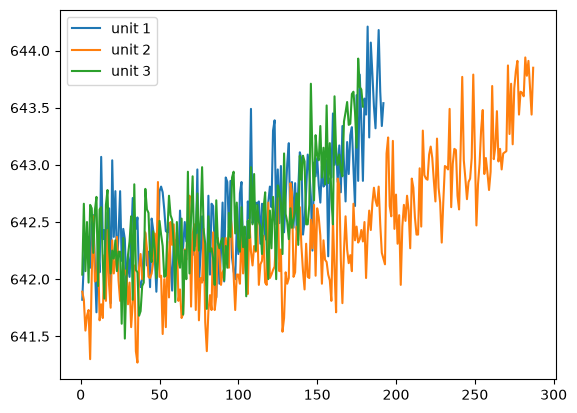

In [13]:
for u in [1, 2, 3]:
    d = df[df.unit == u]
    plt.plot(d["cycle"], d["s2"], label=f"unit {u}")
plt.legend()

In [14]:
import numpy as np

units = df["unit"].unique()
rng = np.random.default_rng(42)
rng.shuffle(units)

train_units = units[:80]
test_units  = units[80:]

train = df[df["unit"].isin(train_units)]
test  = df[df["unit"].isin(test_units)]

print(train.shape, test.shape)
print("تداخل:", set(train_units) & set(test_units))

(16527, 20) (4104, 20)
تداخل: set()


In [15]:
drop_cols = ["unit", "cycle", "RUL"]

X_train = train.drop(columns=drop_cols)
y_train = train["RUL"]

X_test = test.drop(columns=drop_cols)
y_test = test["RUL"]

print(X_train.shape, X_test.shape)
print(X_train.columns.tolist())

(16527, 17) (4104, 17)
['set1', 'set2', 'set3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2))
print("R2  :", round(r2_score(y_test, pred), 4))

MAE : 32.26
RMSE: 43.13
R2  : 0.5959


In [17]:
res = test.copy()
res["pred"] = pred
res["err"] = res["pred"] - res["RUL"]

bins = pd.cut(res["RUL"], [-1, 25, 50, 75, 100, 125])
print(res.groupby(bins)["err"].agg(["mean", "std", "count"]))
print("المجموع:", len(res))

                 mean        std  count
RUL                                    
(-1, 25]    -2.218414  26.183412    520
(25, 50]    25.857979  20.453929    500
(50, 75]    31.706258  22.999801    500
(75, 100]   26.069178  23.787351    500
(100, 125]  12.502748  24.564069    500
المجموع: 4104


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, pred_rf), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_rf)), 2))
print("R2  :", round(r2_score(y_test, pred_rf), 4))

MAE : 29.38
RMSE: 43.22
R2  : 0.5942


In [19]:
sensors = [c for c in df.columns if c.startswith("s")]
W = 20

g = df.groupby("unit")[sensors]

roll_mean = g.rolling(W, min_periods=1).mean().reset_index(level=0, drop=True)
roll_std  = g.rolling(W, min_periods=1).std().reset_index(level=0, drop=True)
delta     = df[sensors] - g.shift(W)

feat = df[["unit", "cycle", "RUL"]].copy()
feat = feat.join(df[sensors])
feat = feat.join(roll_mean.add_suffix("_mean"))
feat = feat.join(roll_std.add_suffix("_std"))
feat = feat.join(delta.add_suffix("_delta"))

print(feat.shape)

(20631, 71)


In [20]:
sensors = [c for c in df.columns if c.startswith("s")]
W = 20

g = df.groupby("unit")[sensors]

roll_mean = g.rolling(W, min_periods=1).mean().reset_index(level=0, drop=True)
roll_std  = g.rolling(W, min_periods=1).std().reset_index(level=0, drop=True)
delta     = df[sensors] - g.shift(W)

feat = df[["unit", "cycle", "RUL"]].copy()
feat = feat.join(df[sensors])
feat = feat.join(roll_mean.add_suffix("_mean"))
feat = feat.join(roll_std.add_suffix("_std"))
feat = feat.join(delta.add_suffix("_delta"))

feat = feat.fillna(0)

print(feat.shape)
print("NaN:", feat.isna().sum().sum())

(20631, 71)
NaN: 0


In [21]:
train = feat[feat["unit"].isin(train_units)]
test  = feat[feat["unit"].isin(test_units)]

drop_cols = ["unit", "cycle", "RUL"]
X_train, y_train = train.drop(columns=drop_cols), train["RUL"]
X_test,  y_test  = test.drop(columns=drop_cols),  test["RUL"]

def evaluate(name, m):
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    print(name,
          "| MAE:",  round(mean_absolute_error(y_test, p), 2),
          "| RMSE:", round(np.sqrt(mean_squared_error(y_test, p)), 2),
          "| R2:",   round(r2_score(y_test, p), 4))
    return p

pred_lin = evaluate("Linear", LinearRegression())
pred_rf  = evaluate("Forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

Linear | MAE: 32.12 | RMSE: 43.52 | R2: 0.5886
Forest | MAE: 30.13 | RMSE: 44.43 | R2: 0.5712


In [22]:
feat2 = feat[feat["cycle"] > W]

train = feat2[feat2["unit"].isin(train_units)]
test  = feat2[feat2["unit"].isin(test_units)]

drop_cols = ["unit", "cycle", "RUL"]
X_train, y_train = train.drop(columns=drop_cols), train["RUL"]
X_test,  y_test  = test.drop(columns=drop_cols),  test["RUL"]

print(X_train.shape, X_test.shape)

pred_lin = evaluate("Linear", LinearRegression())
pred_rf  = evaluate("Forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

(14927, 68) (3704, 68)
Linear | MAE: 29.43 | RMSE: 39.86 | R2: 0.5984
Forest | MAE: 29.2 | RMSE: 43.41 | R2: 0.5237


In [23]:
mask = y_test < 125
print("عدد الصفوف المقيَّمة:", mask.sum(), "من", len(y_test))

for name, p in [("Linear", pred_lin), ("Forest", pred_rf)]:
    yt, pp = y_test[mask], p[mask.values]
    print(name,
          "| MAE:",  round(mean_absolute_error(yt, pp), 2),
          "| RMSE:", round(np.sqrt(mean_squared_error(yt, pp)), 2),
          "| R2:",   round(r2_score(yt, pp), 4))

عدد الصفوف المقيَّمة: 2490 من 3704
Linear | MAE: 22.74 | RMSE: 28.02 | R2: 0.3934
Forest | MAE: 17.34 | RMSE: 25.67 | R2: 0.4906


In [24]:
rows = []
for s in sensors:
    d = df[df.unit == 1][s]
    signal = d.tail(20).mean() - d.head(20).mean()      # الإشارة: التغيّر الكلي
    noise  = (d - d.rolling(11, center=True).mean()).std()  # الضجيج: البواقي
    rows.append([s, round(signal, 3), round(noise, 3), round(abs(signal)/noise, 2)])

snr = pd.DataFrame(rows, columns=["sensor", "signal", "noise", "SNR"])
print(snr.sort_values("SNR", ascending=False).to_string(index=False))

sensor  signal  noise  SNR
   s11   0.782  0.105 7.47
   s12  -1.970  0.284 6.93
   s13   0.211  0.031 6.81
    s4  23.868  3.531 6.76
    s8   0.192  0.029 6.70
    s7  -2.421  0.423 5.73
   s21  -0.281  0.056 5.01
   s14 -14.585  2.971 4.91
   s15   0.087  0.020 4.45
   s20  -0.425  0.099 4.27
   s17   3.600  0.890 4.04
    s2   1.168  0.297 3.93
    s3  12.284  4.161 2.95
    s9  -7.006  4.136 1.69
  set1  -0.000  0.002 0.14
  set2   0.000  0.000 0.07
  set3   0.000  0.000  NaN


In [25]:
life = df.groupby("unit")["cycle"].max()
short = life.idxmin()   # أقصر محرك عمراً
long  = life.idxmax()   # أطولها

print("أقصر:", short, life[short], "| أطول:", long, life[long])

top = ["s11", "s12", "s4", "s7", "s14", "s3"]

early = pd.DataFrame({
    "short": df[(df.unit == short) & (df.cycle <= 20)][top].mean(),
    "long":  df[(df.unit == long)  & (df.cycle <= 20)][top].mean(),
})
early["diff"] = early["short"] - early["long"]
early["noise"] = snr.set_index("sensor").loc[top, "noise"]
early["diff/noise"] = (early["diff"].abs() / early["noise"]).round(2)

print(early.round(3).to_string())

أقصر: 39 128 | أطول: 69 362
        short      long    diff  noise  diff/noise
s11    47.515    47.354   0.160  0.105        1.53
s12   521.553   522.052  -0.500  0.284        1.76
s4   1407.130  1402.390   4.739  3.531        1.34
s7    553.308   553.965  -0.657  0.423        1.55
s14  8126.063  8139.622 -13.559  2.971        4.56
s3   1589.979  1586.657   3.321  4.161        0.80


In [26]:
early = df[df.cycle <= 20].groupby("unit")[sensors].mean()
life  = df.groupby("unit")["cycle"].max()

corr = early.corrwith(life).sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

s3     -0.268
s2     -0.248
s17    -0.231
s4     -0.226
s21     0.218
s11    -0.216
s15    -0.215
s12     0.212
s7      0.210
s20     0.201
s8     -0.200
s13    -0.180
s14     0.110
s9      0.062
set1    0.026
set2    0.011
set3      NaN


In [27]:
last = feat2.groupby("unit").tail(1)
last_test = last[last["unit"].isin(test_units)]

Xl = last_test.drop(columns=drop_cols)
yl = last_test["RUL"]

for name, m in [("Linear", LinearRegression()),
                ("Forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]:
    m.fit(X_train, y_train)
    p = m.predict(Xl)
    print(name,
          "| MAE:",  round(mean_absolute_error(yl, p), 2),
          "| RMSE:", round(np.sqrt(mean_squared_error(yl, p)), 2))

Linear | MAE: 40.56 | RMSE: 50.18
Forest | MAE: 2.94 | RMSE: 3.26


In [28]:
def build(path, W=20, cap=125, with_rul=True):
    cols = ["unit", "cycle"] + [f"set{i}" for i in range(1,4)] + [f"s{i}" for i in range(1,22)]
    d = pd.read_csv(path, sep=r"\s+", header=None, names=cols)

    dead = ["s1","s5","s6","s10","s16","s18","s19","set1","set2","set3"]
    d = d.drop(columns=dead)
    sens = [c for c in d.columns if c.startswith("s")]

    if with_rul:
        d["RUL"] = d.groupby("unit")["cycle"].transform("max") - d["cycle"]
        d["RUL"] = d["RUL"].clip(upper=cap)

    g = d.groupby("unit")[sens]
    out = d.copy()
    out = out.join(g.rolling(W, min_periods=1).mean()
                    .reset_index(level=0, drop=True).add_suffix("_mean"))
    out = out.join(g.rolling(W, min_periods=1).std()
                    .reset_index(level=0, drop=True).add_suffix("_std"))
    out = out.join((d[sens] - g.shift(W)).add_suffix("_delta"))
    return out.fillna(0)

In [29]:
base = "data/"

tr = build(base + "train_FD001.txt")
te = build(base + "test_FD001.txt", with_rul=False)

# آخر صف من كل محرك اختبار = لحظة السؤال
te_last = te.groupby("unit").tail(1).sort_values("unit")

# الأجوبة الحقيقية
y_true = pd.read_csv(base + "RUL_FD001.txt", header=None)[0].clip(upper=125)

print(tr.shape, te_last.shape, len(y_true))

(20631, 59) (100, 58) 100


In [31]:
drop_cols = ["unit", "cycle", "RUL"]
X_tr, y_tr = tr.drop(columns=drop_cols), tr["RUL"]
X_te = te_last.drop(columns=["unit", "cycle"])

print(X_tr.shape, X_te.shape)
print("تطابق الأعمدة:", list(X_tr.columns) == list(X_te.columns))

(20631, 56) (100, 56)
تطابق الأعمدة: True


In [32]:
for name, m in [("Linear", LinearRegression()),
                ("Forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]:
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    print(name,
          "| MAE:",  round(mean_absolute_error(y_true, p), 2),
          "| RMSE:", round(np.sqrt(mean_squared_error(y_true, p)), 2),
          "| R2:",   round(r2_score(y_true, p), 4))

Linear | MAE: 14.1 | RMSE: 17.65 | R2: 0.806
Forest | MAE: 13.66 | RMSE: 19.19 | R2: 0.7707


In [33]:
THR = 30

y_tr_cls  = (y_tr < THR).astype(int)
y_true_cls = (y_true < THR).astype(int)

print(y_tr_cls.value_counts(normalize=True).round(3))
print(y_true_cls.value_counts())

RUL
0    0.855
1    0.145
Name: proportion, dtype: float64
0
0    75
1    25
Name: count, dtype: int64


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr_cls)
pred_cls = clf.predict(X_te)

print("Accuracy:", round(accuracy_score(y_true_cls, pred_cls), 3))
print()
print(confusion_matrix(y_true_cls, pred_cls))
print()
print(classification_report(y_true_cls, pred_cls, target_names=["سليم", "قريب من الفشل"]))

Accuracy: 0.91

[[74  1]
 [ 8 17]]

               precision    recall  f1-score   support

         سليم       0.90      0.99      0.94        75
قريب من الفشل       0.94      0.68      0.79        25

     accuracy                           0.91       100
    macro avg       0.92      0.83      0.87       100
 weighted avg       0.91      0.91      0.90       100



In [35]:
proba = clf.predict_proba(X_te)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2, 0.15]:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cls, p).ravel()
    print(f"عتبة {t}  | أمسك {tp}/25  | فات {fn}  | إنذار كاذب {fp}"
          f"  | استدعاء {tp/(tp+fn):.2f}  | دقة موجبة {tp/(tp+fp):.2f}")

عتبة 0.5  | أمسك 17/25  | فات 8  | إنذار كاذب 1  | استدعاء 0.68  | دقة موجبة 0.94
عتبة 0.4  | أمسك 20/25  | فات 5  | إنذار كاذب 1  | استدعاء 0.80  | دقة موجبة 0.95
عتبة 0.3  | أمسك 21/25  | فات 4  | إنذار كاذب 3  | استدعاء 0.84  | دقة موجبة 0.88
عتبة 0.2  | أمسك 24/25  | فات 1  | إنذار كاذب 5  | استدعاء 0.96  | دقة موجبة 0.83
عتبة 0.15  | أمسك 24/25  | فات 1  | إنذار كاذب 6  | استدعاء 0.96  | دقة موجبة 0.80
